[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Explaining_an_LSTM.ipynb)

# What Is the LSTM Looking At? Explaining a Sequence Model
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

On a table, an explanation is a bar per feature (SHAP, LIME, permutation importance). On a **window** the input is `24 hours x 8 features`, so an explanation is a **heatmap**: *which hours, which features*. Same ideas, one more axis.

Six tools, cheapest first - all on the capstone's one-hour-ahead LSTM:

1. **Permutation importance** by feature - shuffle one feature across windows, watch the error rise
2. **Occlusion** by time step - blank one hour of the window, watch the error rise
3. **Gradient saliency** - the derivative of the prediction with respect to every input cell
4. **Integrated gradients** - saliency done properly: attributions that add up to the prediction
5. **What-if** - warm every window by 10 F and read the model's demand response by month
6. **SHAP** - `GradientExplainer` on the same window, to compare with integrated gradients

The first two need only `predict()` and work on *any* model. The gradient ones need TensorFlow to differentiate through the LSTM - which is the same machinery that trains it.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 19 — What is the LSTM looking at? xAI for sequences
- Frame it against Module 2 / 5512: SHAP and LIME gave you a bar per feature. Here the input is a 24x8 window, so the explanation is a HEATMAP - hours on one axis, features on the other.
- Permutation importance (shuffle a feature across windows, read the MAE jump): demand's own past dominates, then the clock. Say why that is exactly what the persistence baseline told you.
- Occlusion by time step: blank hour -1 (~800 MW worse), hour -2, ... the effect is gone by hour -9 and hour -24 does NOTHING - the model reads the daily rhythm off the clock features, not the window. Ask the class why that is fine at one hour ahead and dangerous at 24.
- Gradient saliency: d(prediction)/d(input) for every cell, tf.GradientTape - the same derivative backprop uses to train. Mean |gradient| heatmap, then one hot July afternoon.
- Integrated gradients: saliency from a baseline (the average window) integrated along the path; the attributions ADD UP to the prediction difference - show the completeness check printing ~0.
- What-if: +10 F on every window -> the model's demand response by month. Summer up, winter down - the U from the capstone EDA, recovered from the model, never from the data.
- SHAP works too - GradientExplainer (a sampled integrated-gradients cousin) gives the same 24x8 heatmap; compare the two side by side. DeepExplainer does NOT work on Keras 3 and SHAP needs NumPy < 2.3 - one sentence, move on. Attention (Module 5) gives you weights for free.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Data and the model to explain

In [2]:
# same prep as the demand capstone: sort, fill, clock features, Demand LAST, train 2017-18 / test 2019
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"]).sort_values("Datetime").set_index("Datetime").ffill()

def add_clock(d):
    d = d.copy()
    d["hour_sin"] = np.sin(2*np.pi*d.index.hour/24);      d["hour_cos"] = np.cos(2*np.pi*d.index.hour/24)
    d["dow_sin"]  = np.sin(2*np.pi*d.index.dayofweek/7);  d["dow_cos"]  = np.cos(2*np.pi*d.index.dayofweek/7)
    return d

feats = ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]   # Demand LAST
data  = add_clock(df.loc["2017-01-01":"2019-12-31"])[feats]
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]

sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # target-only scaler to get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)

def split_sequences(seqs, n_steps, horizon=1):
    """inputs = the past n_steps rows (every column); target = Demand `horizon` steps after the window ends"""
    X, y = [], []
    for i in range(len(seqs) - n_steps - horizon + 1):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps+horizon-1, -1])
    return np.array(X), np.array(y)

n_steps = 24
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (17496, 24, 8) | test: (8736, 24, 8)


In [3]:
model = Sequential([LSTM(32, input_shape=(n_steps, n_features)), Dense(1)])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_1h = sc_y.inverse_transform(model.predict(X_test, verbose=0)).ravel()
print(f"one-step LSTM, 1 hour ahead: MAE {mean_absolute_error(y_true, pred_1h):.1f} MW")

C:\Users\dww05002\AppData\Local\Temp\claude\C--Users-dww05002\7a4f7699-06d8-4736-96e6-9d8a985cfd2a\scratchpad\shapenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


one-step LSTM, 1 hour ahead: MAE 33.4 MW


## 1. Permutation importance by feature

Shuffle one feature's values across the test windows (the window keeps its shape, the feature stops carrying information) and re-score. The rise in MAE is that feature's importance. Model-agnostic - it only needs `predict()`.

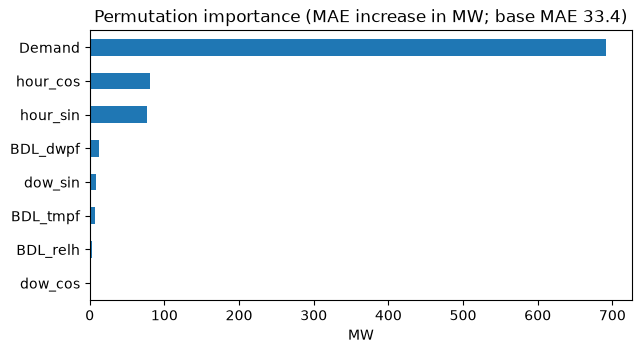

In [4]:
base_mae = mean_absolute_error(y_true, pred_1h)
rng = np.random.default_rng(5509)
perm = {}
for j, f in enumerate(feats):
    Xp = X_test.copy()
    Xp[:, :, j] = Xp[rng.permutation(len(Xp)), :, j]           # shuffle feature j across windows
    perm[f] = mean_absolute_error(y_true, sc_y.inverse_transform(model.predict(Xp, verbose=0)).ravel()) - base_mae
perm = pd.Series(perm).sort_values()
perm.plot(kind="barh", figsize=(7, 3.5), title=f"Permutation importance (MAE increase in MW; base MAE {base_mae:.1f})"); plt.xlabel("MW"); plt.show()

## 2. Occlusion by time step

Now blank one **hour** of the window instead - replace every feature at that step with its training-set mean - and re-score. Which hours of history does the model actually use?

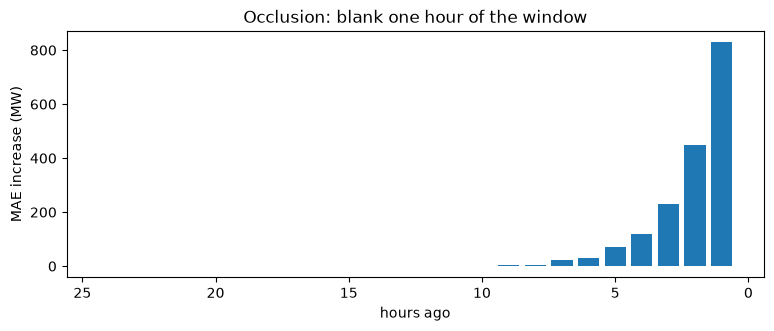

In [5]:
mean_row = tr_s.mean(axis=0)
occ = []
for t in range(n_steps):
    Xo = X_test.copy(); Xo[:, t, :] = mean_row
    occ.append(mean_absolute_error(y_true, sc_y.inverse_transform(model.predict(Xo, verbose=0)).ravel()) - base_mae)
hours_ago = np.arange(n_steps, 0, -1)
plt.figure(figsize=(9, 3.2)); plt.bar(hours_ago, occ); plt.gca().invert_xaxis()
plt.xlabel("hours ago"); plt.ylabel("MAE increase (MW)"); plt.title("Occlusion: blank one hour of the window"); plt.show()

## 3. Gradient saliency

`tf.GradientTape` gives us `d(prediction) / d(input)` for every one of the 24 x 8 cells - the same derivative backprop uses to train the network, pointed at the *inputs* instead of the weights. Average the absolute value over a thousand test windows for the big picture; look at one window for a story.

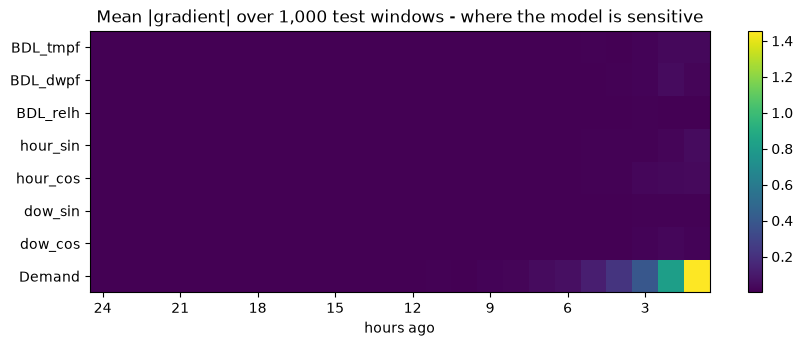

In [6]:
def saliency(model, X):
    x = tf.convert_to_tensor(X, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        out = model(x, training=False)
    return tape.gradient(out, x).numpy()                         # (samples, 24, 8)

def heatmap(M, title, cmap="viridis", center=False):
    plt.figure(figsize=(10, 3.4))
    v = np.abs(M).max()
    plt.imshow(M.T, aspect="auto", cmap=cmap, **({"vmin": -v, "vmax": v} if center else {}))
    plt.yticks(range(len(feats)), feats); plt.xticks(range(0, n_steps, 3), hours_ago[::3]); plt.xlabel("hours ago")
    plt.colorbar(); plt.title(title); plt.show()

sal = np.abs(saliency(model, X_test[:1000])).mean(axis=0)
heatmap(sal, "Mean |gradient| over 1,000 test windows - where the model is sensitive")

predicting 2019-07-20 16:00:00 | actual 6091 MW | predicted 6032 MW


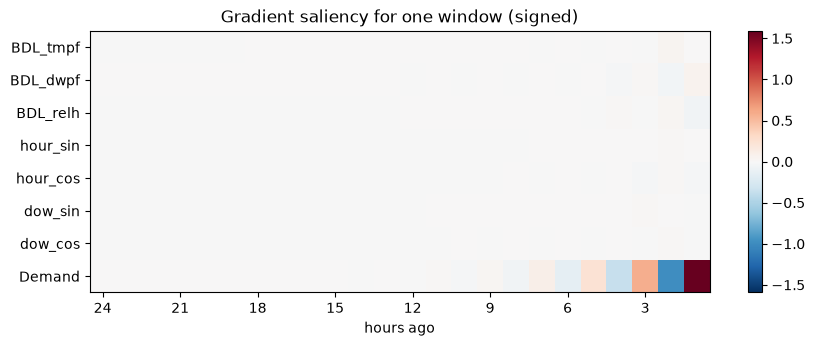

In [7]:
# one window: a hot July afternoon (forecasting 4 PM from the 24 hours before it)
i = np.where(test.index[n_steps:] == pd.Timestamp("2019-07-20 16:00"))[0][0]
print("predicting", test.index[n_steps + i], "| actual", round(y_true[i]), "MW | predicted", round(pred_1h[i]), "MW")
heatmap(saliency(model, X_test[i:i+1])[0], "Gradient saliency for one window (signed)", cmap="RdBu_r", center=True)

## 4. Integrated gradients

Raw gradients say how the prediction would change for a *tiny* nudge - they can be near zero where the network has saturated. **Integrated gradients** fix that: start from a *baseline* window (the average training window), walk in a straight line to the real window, and accumulate the gradient along the way. The attributions then **add up to the prediction difference** from the baseline - the completeness check below should print about zero.

prediction - baseline prediction = +0.5555 (scaled) | sum of attributions = +0.5555  -> completeness gap -0.00000


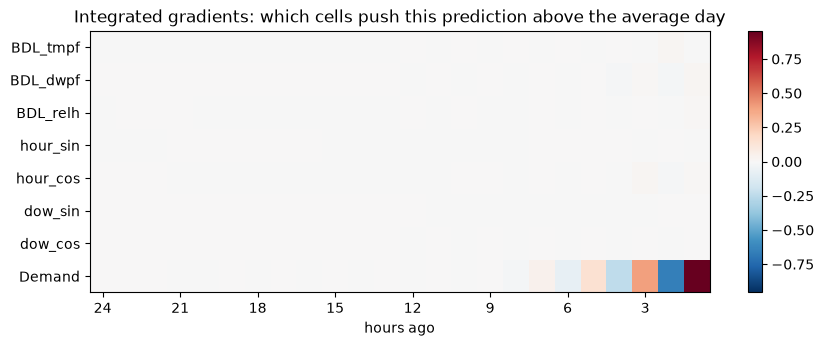

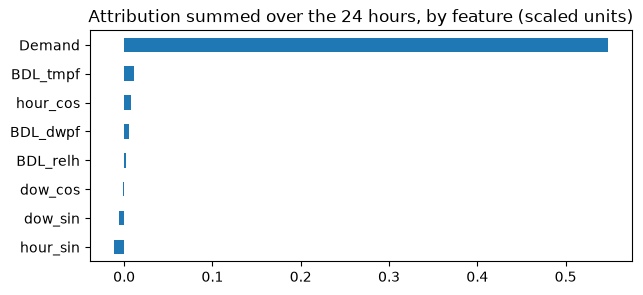

In [8]:
def integrated_gradients(model, x, baseline, steps=50):
    alphas = tf.reshape(tf.linspace(0.0, 1.0, steps + 1), (-1, 1, 1))
    path = tf.cast(baseline[None], tf.float32) + alphas * tf.cast((x - baseline)[None], tf.float32)   # (steps+1, 24, 8)
    with tf.GradientTape() as tape:
        tape.watch(path)
        out = model(path, training=False)
    g = tape.gradient(out, path)
    avg_g = tf.reduce_mean((g[:-1] + g[1:]) / 2.0, axis=0).numpy()          # trapezoid rule along the path
    return (x - baseline) * avg_g

baseline = X_train.mean(axis=0)                                            # the "average day" window
ig = integrated_gradients(model, X_test[i], baseline)
pred_x, pred_b = model.predict(X_test[i:i+1], verbose=0)[0, 0], model.predict(baseline[None], verbose=0)[0, 0]
print(f"prediction - baseline prediction = {pred_x - pred_b:+.4f} (scaled) | sum of attributions = {ig.sum():+.4f}  -> completeness gap {pred_x - pred_b - ig.sum():+.5f}")
heatmap(ig, "Integrated gradients: which cells push this prediction above the average day", cmap="RdBu_r", center=True)
pd.Series(ig.sum(axis=0), index=feats).sort_values().plot(kind="barh", figsize=(7, 3), title="Attribution summed over the 24 hours, by feature (scaled units)"); plt.show()

## 5. What-if: warm the whole window by 10 F

The capstone's EDA showed a U: demand rises when it's cold *and* when it's hot. Did the model learn it? Add 10 F to temperature (and dew point) in every test window, hold everything else, and read the change in the prediction - by month.

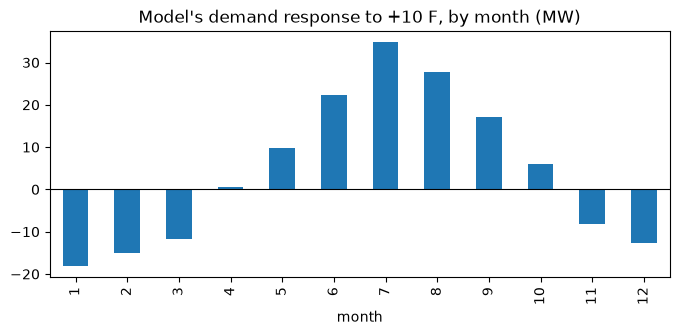

In [9]:
t_idx, d_idx = feats.index("BDL_tmpf"), feats.index("BDL_dwpf")
scale_t = 10.0 / (sc.data_max_[t_idx] - sc.data_min_[t_idx])              # +10 F in scaled units
scale_d = 10.0 / (sc.data_max_[d_idx] - sc.data_min_[d_idx])
Xw = X_test.copy(); Xw[:, :, t_idx] += scale_t; Xw[:, :, d_idx] += scale_d
delta = sc_y.inverse_transform(model.predict(Xw, verbose=0)).ravel() - pred_1h      # MW change per window

months = test.index[n_steps:].month
pd.Series(delta).groupby(months).mean().plot(kind="bar", figsize=(8, 3.2), title="Model's demand response to +10 F, by month (MW)")
plt.axhline(0, color="k", lw=0.8); plt.xlabel("month"); plt.show()

## 6. SHAP on a sequence model

SHAP's `GradientExplainer` is a sampled cousin of integrated gradients (expected gradients over a background set), and it works on a Keras 3 LSTM. Two practical notes: `DeepExplainer` does **not** (it hooks TF1-style graph internals), and SHAP's Numba dependency needs **NumPy < 2.3** - Colab's NumPy is fine, a fresh local TensorFlow install may not be. Colab: `!pip install -q shap`. Local: `pip install "numpy<2.3" shap`.

In [10]:
try:
    import shap
    HAVE_SHAP = True
    print("shap", shap.__version__)
except ImportError:
    HAVE_SHAP = False
    print("shap is not installed - run   !pip install -q shap   (Colab) or   pip install \"numpy<2.3\" shap   (local), then re-run this cell")

C:\Users\dww05002\AppData\Local\Temp\claude\C--Users-dww05002\7a4f7699-06d8-4736-96e6-9d8a985cfd2a\scratchpad\shapenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.51.0


C:\Users\dww05002\AppData\Local\Temp\claude\C--Users-dww05002\7a4f7699-06d8-4736-96e6-9d8a985cfd2a\scratchpad\shapenv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 24, 8))']
  warnings.warn(msg)
C:\Users\dww05002\AppData\Local\Temp\claude\C--Users-dww05002\7a4f7699-06d8-4736-96e6-9d8a985cfd2a\scratchpad\shapenv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 24, 8))']
  warnings.warn(msg)


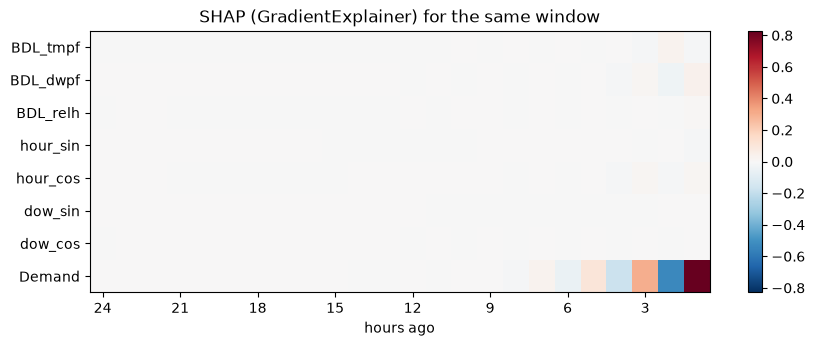

agreement with integrated gradients (correlation over the 24x8 cells): 0.998


In [11]:
if HAVE_SHAP:
    explainer = shap.GradientExplainer(model, X_train[:200])                 # background = 200 training windows
    sv = np.squeeze(np.array(explainer.shap_values(X_test[i:i+1])))          # (24, 8) attributions for the same July window
    heatmap(sv, "SHAP (GradientExplainer) for the same window", cmap="RdBu_r", center=True)
    print("agreement with integrated gradients (correlation over the 24x8 cells):", round(float(np.corrcoef(sv.ravel(), ig.ravel())[0, 1]), 3))

**Module 5 preview:** attention layers produce *weights over the time steps* as part of the forward pass - an explanation you get for free, which is a big reason transformers took over.

## Save the model and use it again

In [12]:
model.save('Explaining_an_LSTM.keras')
reloaded = load_model('Explaining_an_LSTM.keras')
print("reloaded model reproduces the predictions:", np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0)))

reloaded model reproduces the predictions: True


## On your own

- Run the occlusion plot for the **24-hour-ahead** multi-output model from the capstone. Does hour -24 matter more or less when the target is a day away?
- Integrated gradients with a **different baseline** (an all-zeros window, or a cold January night). The attributions change - explain to a manager why that isn't a bug.
- Permutation importance on the *stock* notebook's model. What does it tell you about that near-50% accuracy?
- Warm the window by +10 F but **only in the last 3 hours**. Does the model react as strongly? What does that say about what it memorized?